In [2]:
from torch.utils.data import Dataset
from PIL import Image, UnidentifiedImageError
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

In [3]:
class VideoFrameDataset(Dataset):
    def __init__(self, frame_root_dir, label_root_dir, transform=None):
        self.frame_root_dir = frame_root_dir
        self.transform = transform
        self.frames = []
        self.labels = []

        for video_folder in sorted(os.listdir(frame_root_dir)):
            video_path = os.path.join(frame_root_dir, video_folder)
            label_file = os.path.join(label_root_dir, f'{video_folder}.txt')
            
            if not os.path.exists(label_file):
                continue

            with open(label_file, 'r') as f:
                labels = f.readlines()

            labels = labels[1:]
            
            frame_files = sorted(os.listdir(video_path))
            frame_count = len(frame_files)
            label_count = len(labels)
            count = min(frame_count, label_count)
            print(f"Processing {count} frames and labels for video {video_folder}")

            for i in range(count):
                frame_name = frame_files[i]
                frame_path = os.path.join(video_path, frame_name)
                label_parts = labels[i].strip().split(',')
                valence = label_parts[0]
                arousal = label_parts[1]

                if valence == '-5' or arousal == '-5':
                    continue

                self.frames.append(frame_path)
                self.labels.append([float(valence), float(arousal)])

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx, retry=0):
        try:
            image = Image.open(self.frames[idx])
            label = self.labels[idx]

            if self.transform:
                image = self.transform(image)

            label_tensor = torch.tensor(label)
            return image, label_tensor
        except UnidentifiedImageError:
            if retry < len(self.frames) - 1:
                return self.__getitem__((idx + 1) % len(self.frames), retry + 1)
            else:
                raise RuntimeError("Too many corrupted images, cannot provide a valid batch")



train_transforms  = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomPerspective(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
test_transforms = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

train_dataset = VideoFrameDataset(frame_root_dir='F:\\Aff-Wild2\\Model\\data1', label_root_dir='F:\\Aff-Wild2\\5th_ABAW_Annotations\\mini_va\\train', transform=train_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = VideoFrameDataset(frame_root_dir='F:\\Aff-Wild2\\Model\\data1', label_root_dir='F:\\Aff-Wild2\\5th_ABAW_Annotations\\mini_va\\valid', transform=test_transforms)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


Processing 2501 frames and labels for video 10-60-1280x720
Processing 2639 frames and labels for video 100-29-1080x1920
Processing 5153 frames and labels for video 101-30-1080x1920
Processing 2425 frames and labels for video 104-17-720x480
Processing 10076 frames and labels for video 105
Processing 8163 frames and labels for video 106
Processing 1404 frames and labels for video 106-30-720x1280
Processing 5315 frames and labels for video 107
Processing 4678 frames and labels for video 108
Processing 5504 frames and labels for video 110
Processing 9978 frames and labels for video 110-30-270x480
Processing 7246 frames and labels for video 111
Processing 771 frames and labels for video 111-25-1920x1080
Processing 5915 frames and labels for video 112
Processing 15020 frames and labels for video 113
Processing 2449 frames and labels for video 114
Processing 2517 frames and labels for video 116
Processing 6183 frames and labels for video 116-30-1280x720
Processing 4081 frames and labels for v

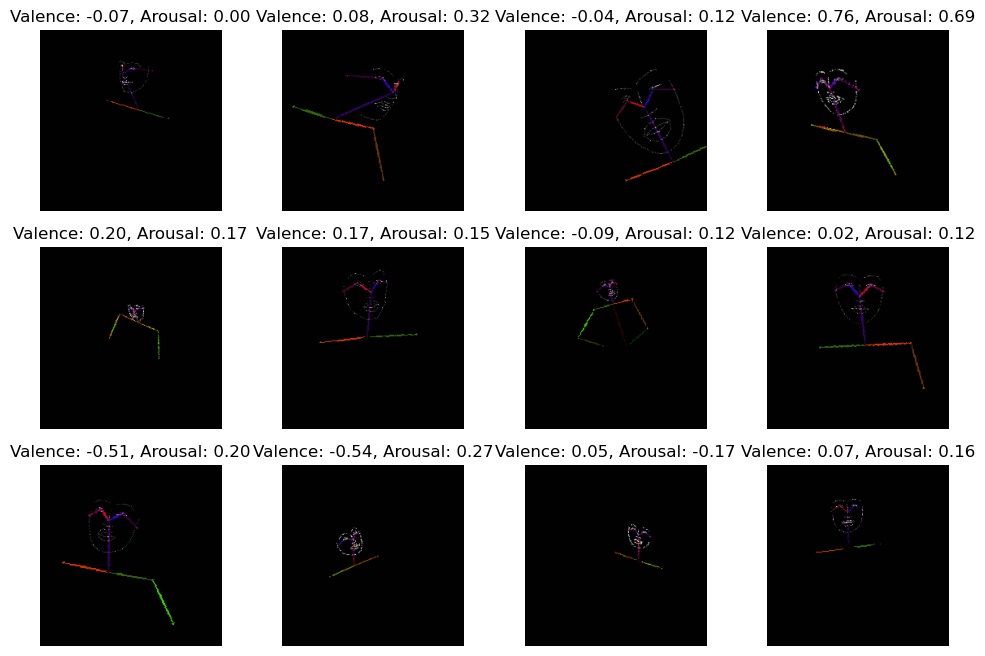

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader):
    images, labels = next(iter(dataloader))
    images = images.numpy()
    labels = labels.numpy()

    fig, axes = plt.subplots(figsize=(12, 8), nrows=3, ncols=4)
    for i, ax in enumerate(axes.flat):
        if i >= images.shape[0]:
            break
        img = np.transpose(images[i], (1, 2, 0))
        img = (img * 255).astype(np.uint8)
        ax.imshow(img)
        ax.set_title(f'Valence: {labels[i][0]:.2f}, Arousal: {labels[i][1]:.2f}')
        ax.axis('off')

    plt.show()
    
show_batch(train_loader)

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = torch.device('cpu')
print(device)

cuda


In [6]:
import torch.nn as nn
import torchvision.models as models
model = models.densenet121(pretrained=True)
print(model)

model.train()
model.classifier = nn.Linear(model.classifier.in_features, 2)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [7]:
# model.apply(he_init)


num_epochs = 10
lr = 1e-5
weight_decay = 5e-4

loss = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

In [8]:
model = model.to(device)
print(next(model.parameters()).device)
print(torch.cuda.is_available())  # Should return True if CUDA is available
print(torch.cuda.current_device())  # Returns the index of the current device
print(torch.cuda.get_device_name(torch.cuda.current_device()))  # Returns the name of the current device



cuda:0
True
0
NVIDIA GeForce RTX 3060 Laptop GPU


In [9]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=10):
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)

            if phase == 'train':
                train_losses.append(epoch_loss)
            else:
                val_losses.append(epoch_loss)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f}')

    return train_losses, val_losses


Epoch 1/10
----------
Train Loss: 0.0974
Val Loss: 0.1683
Epoch 2/10
----------
Train Loss: 0.0738
Val Loss: 0.1678
Epoch 3/10
----------
Train Loss: 0.0652
Val Loss: 0.1668
Epoch 4/10
----------
Train Loss: 0.0599
Val Loss: 0.1627
Epoch 5/10
----------
Train Loss: 0.0559
Val Loss: 0.1686
Epoch 6/10
----------
Train Loss: 0.0530
Val Loss: 0.1811
Epoch 7/10
----------
Train Loss: 0.0507
Val Loss: 0.1785
Epoch 8/10
----------
Train Loss: 0.0486
Val Loss: 0.1854
Epoch 9/10
----------
Train Loss: 0.0469
Val Loss: 0.1969
Epoch 10/10
----------
Train Loss: 0.0455
Val Loss: 0.1976


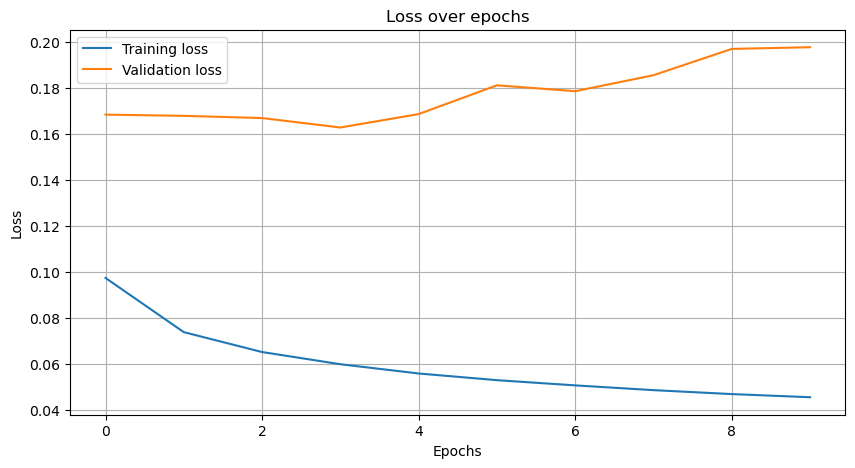

In [10]:
def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training loss')
    plt.plot(val_losses, label='Validation loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

dataloaders = {'train': train_loader, 'val': val_loader}
train_losses, val_losses = train_model(model, dataloaders, loss, optimizer, num_epochs=10)
plot_losses(train_losses, val_losses)


In [11]:
model.eval()
torch.save(model, 'full_model_dence.pth')

transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
img = Image.open("F:\\Aff-Wild2\\Model\\data1\\video95\\video95_000000000001_rendered.png")
img = transform(img).unsqueeze(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img = img.to(device)

with torch.no_grad():
    outputs = model(img)
    _, predicted = torch.max(outputs, 1)
    
print(f'Predicted values: {outputs[0].tolist()}')

Predicted values: [0.48134687542915344, 0.5618922710418701]


In [12]:
test_dataset = VideoFrameDataset(frame_root_dir='F:\\Aff-Wild2\\Model\\data1', label_root_dir='F:\\Aff-Wild2\\5th_ABAW_Annotations\\mini_va\\valid-1', transform=test_transforms)
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
def validate(model, dataloader):
    total_loss = 0
    criterion = nn.MSELoss()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    print(f'Validation Loss: {average_loss:.4f}')

validate(model, test_loader)


Validation Loss: 0.1976
